# Laboratorio 5 — Clasificación Multiclase One-vs-All: Tiny ImageNet-200

En este cuadernillo se entrenan los parámetros $\theta$ de un modelo de **regresión logística
one-vs-all** (clasificación multiclase) para reconocer imágenes del dataset **Tiny ImageNet-200**
(Stanford CS231n), que contiene $100\,000$ imágenes a color de $64 \times 64$ píxeles distribuidas
en **200 clases** con exactamente 500 ejemplos por clase.

| Requisito del laboratorio | Valor obtenido |
|---------------------------|----------------|
| Ejemplos $m \geq 50000$ | $m = 100\,000$ |
| Resolución $\geq 20\times20$ px | $64 \times 64$ (procesadas a $20 \times 20 \times 3$) |
| Clasificación multiclase | 200 clases balanceadas (500 ejemplos por clase) |

El flujo completo es: carga y exploración con **Pandas** → preprocesamiento de imágenes →
partición estratificada **80% / 20%** (entrenamiento/prueba) → implementación *one-vs-all* con
descenso por el gradiente por mini-lotes → gráficos de **costo** y **precisión** → validación
sobre el 20% reservado con matriz de confusión, exactitud top-1/top-5 y predicciones individuales.

In [1]:
import io
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as pyplot
from PIL import Image
from sklearn.model_selection import train_test_split

import torch
print(torch.cuda.is_available())

%matplotlib inline
pyplot.rcParams['figure.dpi'] = 110

True


## 1. Carga y exploración del dataset con Pandas

El dataset está almacenado en formato **Parquet**, un formato columnar comprimido ideal para
tablas grandes. Cada fila contiene dos columnas:

- `image`: estructura con los **bytes** de la imagen codificada (PNG/JPEG) y su ruta original;
- `label`: entero entre 0 y 199 que indica la clase a la que pertenece la imagen.

Pandas permite cargarlo directamente con `read_parquet` y operar sobre sus columnas para todo el
preprocesamiento posterior. El archivo incluye además una partición `valid.parquet` con 10 000
imágenes adicionales, que no se utiliza: según lo pedido, la validación se realiza con un **20%
reservado del propio dataset** y nunca visto durante el entrenamiento.

In [2]:

device = torch.device('cuda')
df = pd.read_parquet('./dataset/train.parquet')

print('Dimensiones (m filas):', df.shape)
print('Columnas:', list(df.columns))
print('Valores nulos:', df.isna().sum().sum())
print('Rango de etiquetas:', df['label'].min(), '-', df['label'].max(),
      '| clases únicas:', df['label'].nunique())
df.head()

Dimensiones (m filas): (100000, 2)
Columnas: ['image', 'label']
Valores nulos: 0
Rango de etiquetas: 0 - 199 | clases únicas: 200


,image,label
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
4,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0


### 1.1 Verificación del balance de clases

Un requisito del laboratorio es que el dataset esté balanceado. Con Pandas se cuenta cuántos
ejemplos hay por clase:

Ejemplos por clase -> min: 500 | max: 500 | media: 500.0


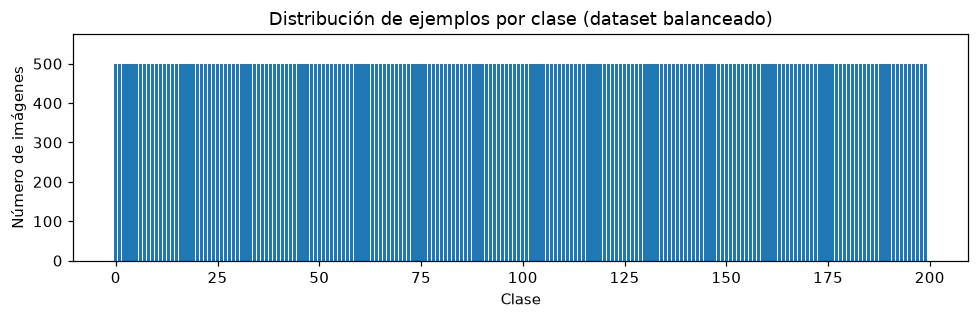

In [3]:
conteo = df['label'].value_counts().sort_index()
print('Ejemplos por clase -> min:', conteo.min(), '| max:', conteo.max(),
      '| media:', round(conteo.mean(), 2))

fig, ax = pyplot.subplots(figsize=(9, 3))
ax.bar(conteo.index, conteo.values, color='tab:blue')
ax.set_xlabel('Clase')
ax.set_ylabel('Número de imágenes')
ax.set_title('Distribución de ejemplos por clase (dataset balanceado)')
ax.set_ylim(0, conteo.max() * 1.15)
pyplot.tight_layout()
pyplot.show()

In [4]:
modos, tamanios = [], []
for d in df['image'].iloc[:3000]:
    with Image.open(io.BytesIO(d['bytes'])) as im:
        modos.append(im.mode)
        tamanios.append(im.size)

print('Modos de color (muestra de 3000):', pd.Series(modos).value_counts().to_dict())
print('Tamaños (muestra de 3000):', pd.Series(tamanios).value_counts().to_dict())

Modos de color (muestra de 3000): {'RGB': 2993, 'L': 7}
Tamaños (muestra de 3000): {(64, 64): 3000}


Todas las imágenes miden $64 \times 64$ píxeles ($\geq 20\times20$) y casi todas son RGB,
con algunas en escala de grises (`L`), por lo que durante el preprocesamiento se convertirá
todo a RGB.

### 1.2 Visualización de las imágenes originales

Las imágenes vienen codificadas como bytes, así que se decodifican con `PIL` para poder
visualizarlas junto a su etiqueta:

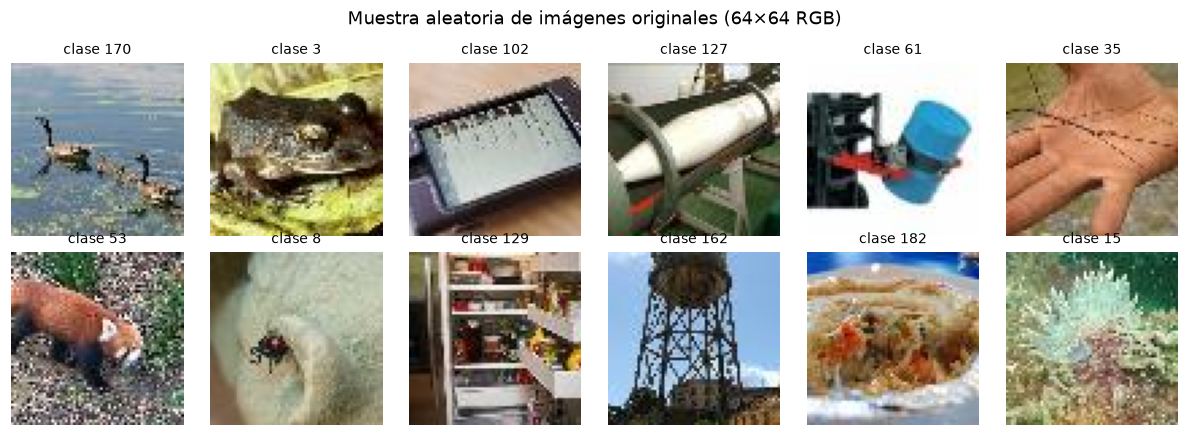

In [5]:
rng_vis = np.random.default_rng(0)
indices_vis = rng_vis.choice(len(df), 12, replace=False)

fig, axes = pyplot.subplots(2, 6, figsize=(11, 4))
for ax, i in zip(axes.ravel(), indices_vis):
    fila = df.iloc[i]
    ax.imshow(Image.open(io.BytesIO(fila.image['bytes'])))
    ax.set_title('clase ' + str(int(fila.label)), fontsize=9)
    ax.axis('off')
fig.suptitle('Muestra aleatoria de imágenes originales (64×64 RGB)')
pyplot.tight_layout()
pyplot.show()

## 2. Preprocesamiento con Pandas

Cada imagen $64\times64\times3$ tiene $12\,288$ valores; entrenar 200 clasificadores one-vs-all
sobre vectores tan largos con NumPy sería innecesariamente costoso, porque la mayor parte de esa
información son bordes y fondo poco informativos. Se aplica entonces:

1. **Conversión a RGB** (unifica las pocas imágenes en escala de grises);
2. **Redimensionamiento a $20 \times 20$ px** — misma resolución usada en el cuadernillo de dígitos
   revisado en clase y aún dentro del requisito ($\geq 20\times20$);
3. **Aplanado** a un vector de $20 \cdot 20 \cdot 3 = 1200$ características por ejemplo.

Con `Series.map` de Pandas se procesa toda la columna de bytes y se apila el resultado en la
matriz de diseño $X \in \mathbb{R}^{100000 \times 1200}$:

In [6]:
def procesar_imagen(bytes_img):
    """Decodifica la imagen, la lleva a RGB 20x20 y la aplana a un vector de 1200 valores."""
    im = Image.open(io.BytesIO(bytes_img)).convert('RGB')
    im = im.resize((20, 20), Image.BILINEAR)
    return np.asarray(im, dtype=np.uint8).ravel()

t0 = time.time()
X = np.stack(df['image'].map(lambda d: procesar_imagen(d['bytes'])))
y = df['label'].values.astype(int)

print('X:', X.shape, X.dtype, '| y:', y.shape, '| tiempo: %.1fs' % (time.time() - t0))
print('Rango de intensidades:', X.min(), '-', X.max())

X: (100000, 1200) uint8 | y: (100000,) | tiempo: 14.6s
Rango de intensidades: 0 - 255


Al igual que en el cuadernillo de dígitos, se visualiza una muestra de 100 ejemplos ya
preprocesados para comprobar que siguen siendo reconocibles tras la reducción:

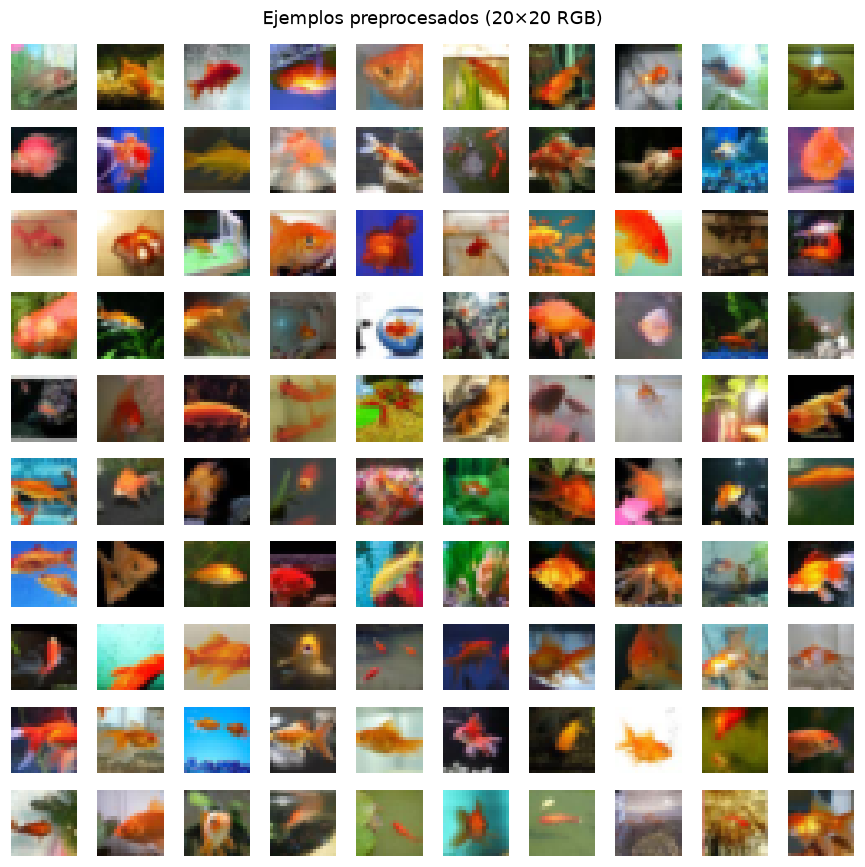

In [7]:
def displayData(X_data, ejemplo_ancho=20, filas=10, cols=10):
    """Muestra una grilla filas x cols con los primeros ejemplos de X_data."""
    fig, axes = pyplot.subplots(filas, cols, figsize=(8, 8))
    for i, ax in enumerate(axes.ravel()):
        ax.imshow(X_data[i].reshape(ejemplo_ancho, ejemplo_ancho, 3))
        ax.axis('off')
    pyplot.suptitle('Ejemplos preprocesados (20×20 RGB)')
    pyplot.tight_layout()
    pyplot.show()

displayData(X)

## 3. Partición entrenamiento/prueba (80% - 20%)

Se reserva el **80% de los ejemplos para entrenamiento** y el **20% para prueba**. La partición es
**estratificada** (`stratify=y`) para que las proporciones de las 200 clases se conserven en ambos
conjuntos y el balance del dataset no se pierda. Los datos de prueba **no intervienen** en el
entrenamiento ni en el cálculo de los parámetros de normalización:

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print('Entrenamiento:', X_train.shape[0], 'ejemplos | Prueba:', X_test.shape[0], 'ejemplos')

conteo_train = pd.Series(y_train).value_counts()
conteo_test = pd.Series(y_test).value_counts()
print('Clases en entrenamiento -> min:', conteo_train.min(), '| max:', conteo_train.max())
print('Clases en prueba        -> min:', conteo_test.min(), '| max:', conteo_test.max())

Entrenamiento: 80000 ejemplos | Prueba: 20000 ejemplos
Clases en entrenamiento -> min: 400 | max: 400
Clases en prueba        -> min: 100 | max: 100


### 3.1 Normalización de características

La media $\mu$ y desviación estándar $\sigma$ se calculan **únicamente con el conjunto de
entrenamiento** y luego se aplican a ambos conjuntos, evitando fugas de información. Si alguna
característica tuviera $\sigma = 0$ se reemplaza por 1 para evitar divisiones por cero:

In [9]:
def featureNormalize(X_in):
    """Normaliza cada columna restanto la media y dividiendo por la desviación estándar."""
    mu = np.mean(X_in, axis=0)
    sigma = np.std(X_in, axis=0)
    sigma[sigma == 0] = 1
    X_norm = (X_in - mu) / sigma
    return X_norm, mu, sigma


X_train_norm, mu, sigma = featureNormalize(X_train.astype(np.float32))
X_test_norm = (X_test.astype(np.float32) - mu) / sigma

In [10]:
X_train_tensor = torch.tensor(X_train_norm, dtype=torch.float32, device='cuda')
y_train_tensor = torch.tensor(y_train, dtype=torch.long, device='cuda')

X_test_tensor = torch.tensor(X_test_norm, dtype=torch.float32, device='cuda')
y_test_tensor = torch.tensor(y_test, dtype=torch.long, device='cuda')

def softmax(x):
    return torch.exp(x) / torch.exp(x).sum(dim=-1, keepdim=True)


def cross_entropy(output, target):
    logits = output[torch.arrange(len(output)), target]
    loss = - logits + torch.log(torch.sum(torch.exp(output), dim=-1))
    loss = loss.mean()
    return loss

print(X_train_tensor.shape)


D_in, H, D_out = 1200, 64, 200

w1 = torch.tensor(np.random.normal(loc=0.0, 
                                   scale=np.sqrt(2/(D_in+H)),
                                   size=(D_in, H)), 
                                   requires_grad=True,
                                   device='cuda',
                                   dtype=torch.float)

b1 = torch.zeros(H, requires_grad=True, device='cuda', dtype=torch.float)

w2 = torch.tensor(np.random.normal(loc=0.0,
          scale = np.sqrt(2/(D_out+H)),
          size = (H, D_out)), requires_grad=True, device="cuda", dtype=torch.float)
b2 = torch.zeros(D_out, requires_grad=True, device="cuda", dtype=torch.float)

epochs = 100
lr = 0.8
log_each = 10
l = []
for e in range(1, epochs+1):
    # forward
    h = X_train_tensor.mm(w1) + b1
    h_relu = h.clamp(min=0) # relu
    y_pred = h_relu.mm(w2) + b2

    # loss
    # print(y_pred, Y_t)
    # print(y_pred.shape, Y_t.shape)
    loss = cross_entropy(y_pred, y_train_tensor)
    l.append(loss.item())

    # Backprop (calculamos todos los gradientes automáticamente)
    loss.backward()

    with torch.no_grad():
        # update pesos
        w1 -= lr * w1.grad
        b1 -= lr * b1.grad
        w2 -= lr * w2.grad
        b2 -= lr * b2.grad

        # ponemos a cero los gradientes para la siguiente iteración
        # (sino acumularíamos gradientes)
        w1.grad.zero_()
        w2.grad.zero_()
        b1.grad.zero_()
        b2.grad.zero_()

    if not e % log_each:
        print(f"Epoch {e}/{epochs} Loss {np.mean(l):.5f}")


def evaluate(x):
    h = x.mm(w1) + b1
    h_relu = h.clamp(min=0)
    y_pred = h_relu.mm(w2) + b2
    y_probas = softmax(y_pred)
    return torch.argmax(y_probas, axis=1)


from sklearn.metrics import accuracy_score

y_pred = evaluate(X_test_tensor)
acc = accuracy_score(y_test_tensor.cpu().numpy(), y_pred.cpu().numpy())

print(f"acc: {acc * 100:.2f}%")

r, c = 3, 5
fig = plt.figure(figsize=(2*c, 2*r))
test_imgs, test_labs = [], []
for _r in range(r):
    for _c in range(c):
        plt.subplot(r, c, _r*c + _c + 1)
        ix = random.randint(0, len(X_test)-1)
        img = X_test[ix]
        y_pred = evaluate(torch.tensor([img]).float().cuda())[0]
        plt.imshow(img.reshape(28,28), cmap='gray')
        plt.axis("off")
        plt.title(f"{y_test[ix]}/{y_pred}", color="green" if y_test[ix] == y_pred else "red")
plt.tight_layout()
plt.show()

torch.Size([80000, 1200])


AttributeError: module 'torch' has no attribute 'arrange'